In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.ticker as mticker
import pandas as pd


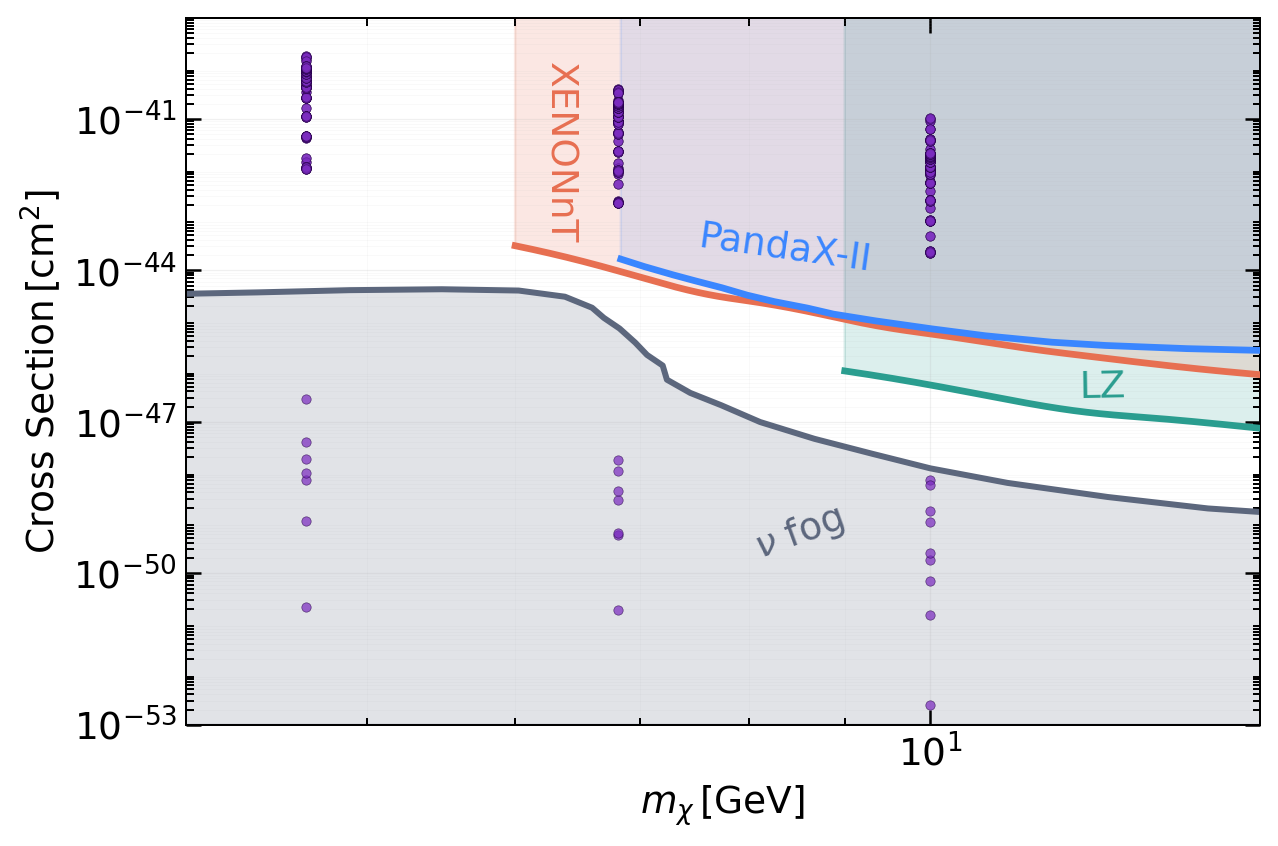

In [16]:
GEV2_TO_CM2 = 0.389379e-27   # 1 GeV^-2 to cm^2
M_N_GEV = 0.939              # nucleon mass = 0.939 GeV
F_N = 0.30                   # Hambye value for f = 0.3


def sigma_SI(mx, r, gX, beta, mh1=125, vEW=246.0, fN=F_N, mN=M_N_GEV):
    """
    σ_SI per nucleon in cm^2 
    """
    mh2=r*mx
    mu = (mN * mx) / (mN + mx)  # masa reducida DM-nucleón
    

    sig_gev2 = 1/(16*np.pi)*(mu**2)*(fN**2)*(gX**2)*(np.sin(2*beta)**2)*(mN**2)/(vEW**2)*((mh2**2-mh1**2)/((mh2**2)*(mh1**2)))**2
    return sig_gev2 * GEV2_TO_CM2

#Values of SI based on AnalyzeSweep
f1=("../data/SweepHiddenVector_Relic.csv")
relicPoints=pd.read_csv(f1).copy()

relicPoints["SI"]=sigma_SI(relicPoints["mx"], relicPoints["r"], relicPoints["gX"], relicPoints["beta"], mh1=125, vEW=246.0, fN=F_N, mN=M_N_GEV)
vec1=relicPoints["mx"]
vec2=relicPoints["SI"]

#Bounds of LZ

texto="{{9., 1.01992*10**-46}, {11., 2.75749*10**-47}, {13.,1.22912*10**-47}, {16., 6.00362*10**-48}, {17., 5.33482*10**-48}, {19.,3.89685*10**-48}, {21., 3.32373*10**-48}, {23., 2.96849*10**-48}, {26., 2.61558*10**-48}, {29., 2.36842*10**-48}, {32.,2.28731*10**-48}, {36., 2.10423*10**-48}, {40., 2.11533*10**-48}, {43., 2.23528*10**-48}, {46., 2.1977*10**-48}, {65., 2.50572*10**-48}, {91., 3.19592*10**-48}, {129., 3.88153*10**-48}, {182., 5.59417*10**-48}, {256., 7.65692*10**-48}, {361., 1.06284*10**-47}, {508., 1.43934*10**-47}, {1008., 2.94202*10**-47}, {2000., 5.81933*10**-47}, {5000., 1.4227*10**-46}, {10000., 2.88442*10**-46}}"
lista = eval(texto.replace("{","[").replace("}","]"))
x,y=zip(*lista)

interpolation = interp1d(x,y,kind="cubic")
x_interpol=np.logspace(np.log10(min(x)),np.log10(max(x)),10000)
y_interpol=interpolation(x_interpol)

#Bounds of Xenon
text2="{{6.00, 3.081*10**-44}, {7.00, 7.318*10**-45}, {8.00, 2.477*10**-45}, {9.00, 1.072*10**-45}, {10.00, 5.527*10**-46}, {11.00, 3.248*10**-46}, {12.00, 2.108*10**-46}, {13.00, 1.477*10**-46}, {15.00, 8.595*10**-47}, {17.00, 5.866*10**-47}, {20.00, 4.005*10**-47}, {23.00, 3.160*10**-47}, {25.00, 2.838*10**-47}, {26.00, 2.719*10**-47}, {28.14, 2.587*10**-47}, {30.00, 2.616*10**-47}, {35.00, 2.761*10**-47}, {40.00, 2.960*10**-47}, {45.00, 3.188*10**-47}, {50.00, 3.431*10**-47}, {55.00, 3.683*10**-47}, {60.00, 3.939*10**-47}, {70.00, 4.458*10**-47}, {75.00, 4.722*10**-47}, {80.00, 4.988*10**-47}, {90.00, 5.527*10**-47}, {100.00,6.074*10**-47}, {125.00, 7.468*10**-47}, {150.00, 8.887*10**-47}, {200.00, 1.176*10**-46}, {500.00, 2.857*10**-46}, {1000.00, 5.636*10**-46}, {10000.00, 5.636*10**-45}}"
lista2 = eval(text2.replace("{","[").replace("}","]"))
x2,y2=zip(*lista2)


interpolation2 = interp1d(x2,y2,kind="cubic")
x2_interpol=np.logspace(np.log10(min(x2)),np.log10(max(x2)),10000)
y2_interpol=interpolation2(x2_interpol)

#Neutrino Fog

f2=("../DirectDectection/nufog.csv")
nufog=pd.read_csv(f2).copy()
mascara=(nufog["masa"]<=1e4)
nufog_clean=nufog[mascara]
x_nu=nufog_clean["masa"]
y_nu=nufog_clean["nufog"]


#Bounds of PANDA X II
f_pandaX=("../DirectDectection/pandaX_II.csv")
pandaX=pd.read_csv(f_pandaX).copy()
mask_pandaX=(pandaX["masa"]<=1e4)
pandaX_clean=pandaX[mask_pandaX]
x_pandaX=pandaX_clean["masa"]
y_pandaX=pandaX_clean["sigma_si"]

#Plot
fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=180)

# Paleta estilo del otro plot
c_lz      = "#2A9D8F"   # verde petróleo
c_xenon   = "#E76F51"   # naranja rojizo
c_pandax  = "#3A86FF"   # azul brillante
c_nufog   = "#5C677D"   # gris azulado
c_points  = "#7B2CBF"   # morado

# Áreas suaves
ax.fill_between(x_nu, 1e-53, y_nu,
                color=c_nufog, alpha=0.18, label="neutrino fog", zorder=0)

ax.fill_between(x_interpol, y_interpol, 1e-33,
                color=c_lz, alpha=0.16, label="LZ 2024", zorder=1)

ax.fill_between(x2_interpol, y2_interpol, 1e-33,
                color=c_xenon, alpha=0.16, label="XENONnT", zorder=1)

ax.fill_between(x_pandaX, y_pandaX, 1e-33,
                color=c_pandax, alpha=0.13, label="Panda X II", zorder=1)

# Líneas
ax.loglog(x_nu, y_nu,
          color=c_nufog, linewidth=2.4, label="neutrino fog", zorder=2)

ax.loglog(x_interpol, y_interpol,
          color=c_lz, linewidth=2.7, label="LZ 2024", zorder=3)

ax.loglog(x2_interpol, y2_interpol,
          color=c_xenon, linewidth=2.7, label="XENONnT", zorder=3)

ax.loglog(x_pandaX, y_pandaX,
          color=c_pandax, linewidth=2.7, label="PANDA X II", zorder=3)

# Relic points
ax.scatter(vec1, vec2,
           s=14,
           color=c_points,
           alpha=0.72,
           edgecolors="#240046",
           linewidths=0.25,
           label="relic points",
           zorder=4)

# Textos sobre las curvas
ax.text(12, 3e-47, "LZ",
        fontsize=15, color=c_lz, rotation=1)

ax.text(6.2, 5e-44, "XENONnT",
        fontsize=15, color=c_xenon, rotation=-90)

ax.text(7.5, 1e-44, "PandaX-II",
        fontsize=15, color=c_pandax, rotation=-8)

ax.text(8, 2e-50, r'$\nu$ fog',
        fontsize=15, color=c_nufog, rotation=20)

# Ejes
ax.set_xlabel(r'$m_{\chi}\,[\mathrm{GeV}]$', fontsize=15)
ax.set_ylabel(r'$\mathrm{Cross\ Section}\,[\mathrm{cm}^{2}]$', fontsize=15)

ax.set_xlim(4, 15)
ax.set_ylim(1e-53, 1e-39)

xmaj = 10.0**np.arange(0, 4, 1)
ymaj = 10.0**np.arange(-53, -33, 3)

ax.xaxis.set_major_locator(mticker.FixedLocator(xmaj))
ax.yaxis.set_major_locator(mticker.FixedLocator(ymaj))

ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))

ax.xaxis.set_minor_locator(
    mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=1000)
)
ax.yaxis.set_minor_locator(
    mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=1000)
)

ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.tick_params(axis='both', which='major',
               direction='in', top=True, right=True,
               length=6, width=1.0, labelsize=15)

ax.tick_params(axis='both', which='minor',
               direction='in', top=True, right=True,
               length=3, width=0.8)

ax.grid(True, which="major", alpha=0.18, linewidth=0.5)
ax.grid(True, which="minor", alpha=0.08, linewidth=0.35)

# Si quieres leyenda, descomenta:
# ax.legend(frameon=True, framealpha=0.18, loc="best", fontsize=11)

plt.tight_layout()
plt.savefig("direct_detection_1.png", bbox_inches="tight", dpi=180)
plt.show()


